In [1]:
from mockfactory import RandomCutskyCatalog, setup_logging, Catalog
import desimodel.footprint
from mpytools import Catalog
import matplotlib.pyplot as plt
# os.environ['DESI_LOGLEVEL'] = 'ERROR'
from fiber_assignment import apply_fiber_assignment, build_tiles_for_fa, read_sky_targets, compute_completeness_weight
import fitsio
from mpi4py import MPI
import logging
import numpy as np
import pandas as pd


In [2]:
from fiber_assignment import run_FA
from mockfactory import Catalog
cutsky_lrg = Catalog.read('/pscratch/sd/e/epaillas/acm/dr2/hods/cutsky/v0.0/c000_ph000/LRG_NGC_hod000.dat.fits')

# Select a small region for testing
mask = (cutsky_lrg['RA']<205) &(cutsky_lrg['RA']> 175) & (cutsky_lrg['DEC']>35) & (cutsky_lrg['DEC']<45)
cutsky_lrg = cutsky_lrg[mask]


In [3]:
cutsky_FA = run_FA(cutsky_lrg, release='Y3', program='dark', npasses=1, add_random_tracers=True, tracer='LRG', plot_output=False, path_to_save=None)

MPSort: element size is large (90) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669


INFO:utils.py:206:get_fba_use_fabs: fba_use_fabs cutoff dates: 2019-09-16T00:00:00+00:00 = 0, 2025-05-12T19:00:00+00:00 = 1
INFO:utils.py:227:get_fba_use_fabs: pick fba_use_fabs = 0 for rundate = 2021-05-14T23:48:14+00:00
INFO:utils.py:175:get_obsdate: rundate=2021-05-14T23:48:14+00:00 < rundate_cutoff=2025-05-02T19:00:00+00:00 -> (obsdate, is_after_cutoff)=(2022-07-01, False)
INFO:utils.py:175:get_obsdate: rundate=2021-05-14T23:48:14+00:00 < rundate_cutoff=2025-05-02T19:00:00+00:00 -> (obsdate, is_after_cutoff)=(2022-07-01, False)
INFO: targets:	[' ']
INFO: sky:	[]
INFO: gfafile:	None
INFO: footprint:	None
INFO: tiles:	None
INFO: rundate:	2021-05-14T23:48:14+00:00
INFO: obsdate:	2022-07-01
INFO: ha:	0.0
INFO: fieldrot:	None
INFO: fieldrot_corr:	False
INFO: dir:	out_fiberassign_2021-05-14T23:48:14+00:00
INFO: prefix:	fba-
INFO: split:	False
INFO: standards_per_petal:	10
INFO: sky_per_petal:	40
INFO: sky_per_slitblock:	1
INFO: margin_pos:	0.05
INFO: margin_petal:	0.4
INFO: margin_gfa:	0

INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


INFO: Tile 1338 at RA,Dec 173.262,36.385 obscond: 1 HA: 0.0 obstime: 2022-07-01T00:00:00.000
INFO: Found 273 targets near tile and matching obscond
INFO: Computing targets available to all tile / locations:  0.18 seconds (1 calls)
INFO: Computing tile / locations available to all objects:  0.18 seconds (1 calls)
INFO: Assignment constructor project targets:  0.02 seconds (1 calls)
INFO: Tile 1338: Start: SCIENCE: 0, STANDARD: 0, SKY: 605
INFO: assign unused science:  considering 5000 locations of positioner type "POS"
INFO: assign unused science:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Assign science targets to unused locations:  0.00 seconds (1 calls)
INFO: Tile 1338: After assigning unused fibers to science targets: SCIENCE: 74, SCIENCE not STANDARD: 74, STANDARD: 0, SKY: 605
INFO: redist:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Redistribute science targets:  0.00 seconds (1 calls)
INFO: Tile 1338: After redistributing science targets: SCIENCE: 74, SCIENCE n

INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


...

INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


INFO: Tile 2187 at RA,Dec 191.371,38.031 obscond: 1 HA: 0.0 obstime: 2022-07-01T00:00:00.000
INFO: Found 8637 targets near tile and matching obscond
INFO: Computing targets available to all tile / locations:  0.72 seconds (1 calls)
INFO: Computing tile / locations available to all objects:  0.30 seconds (1 calls)
INFO: Assignment constructor project targets:  0.06 seconds (1 calls)
INFO: Tile 2187: Start: SCIENCE: 0, STANDARD: 0, SKY: 617
INFO: assign unused science:  considering 5000 locations of positioner type "POS"
INFO: assign unused science:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Assign science targets to unused locations:  0.27 seconds (1 calls)
INFO: Tile 2187: After assigning unused fibers to science targets: SCIENCE: 3194, SCIENCE not STANDARD: 3194, STANDARD: 0, SKY: 617
INFO: redist:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Redistribute science targets:  0.01 seconds (1 calls)
INFO: Tile 2187: After redistributing science targets: SCIENCE: 3194, SC

INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


INFO: Tile 2219 at RA,Dec 187.319,36.581 obscond: 1 HA: 0.0 obstime: 2022-07-01T00:00:00.000
INFO: Found 9333 targets near tile and matching obscond
INFO: Computing targets available to all tile / locations:  0.33 seconds (1 calls)
INFO: Computing tile / locations available to all objects:  0.32 seconds (1 calls)
INFO: Assignment constructor project targets:  0.01 seconds (1 calls)
INFO: Tile 2219: Start: SCIENCE: 0, STANDARD: 0, SKY: 566
INFO: assign unused science:  considering 5000 locations of positioner type "POS"
INFO: assign unused science:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Assign science targets to unused locations:  0.34 seconds (1 calls)
INFO: Tile 2219: After assigning unused fibers to science targets: SCIENCE: 3334, SCIENCE not STANDARD: 3334, STANDARD: 0, SKY: 566
INFO: redist:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Redistribute science targets:  0.01 seconds (1 calls)
INFO: Tile 2219: After redistributing science targets: SCIENCE: 3334, SC

MPSort: element size is large (90) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669
MPSort: element size is large (35) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669
MPSort: element size is large (35) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669


/global/homes/a/arocher/.local/lib/python3.12/site-packages/skyproj/_skyproj.py:628: FutureWarning: skyproj.scatter() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.scatter()
  warnings.warn(
/global/homes/a/arocher/.local/lib/python3.12/site-packages/skyproj/_skyproj.py:673: FutureWarning: skyproj.legend() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.legend()
  warnings.warn(


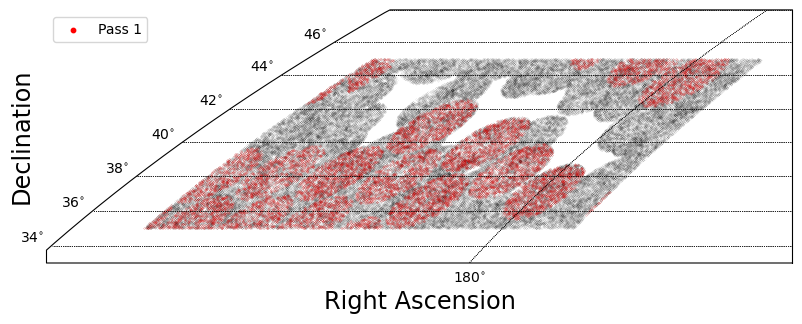

In [5]:
import skyproj
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

sp = skyproj.DESSkyproj(ax=ax, extent=[178,209, 33, 48], fontsize=8)

sp.scatter(cutsky_lrg['RA'], cutsky_lrg['DEC'], s=0.001, c='k')
sp.scatter(cutsky_FA['RA'][cutsky_FA['OBS_PASS'].T[0]], cutsky_FA['DEC'][cutsky_FA['OBS_PASS'].T[0]], s=0.01,c='r') 

sp.scatter(0,0, s=10,c='r', label='Pass 1') 




sp.legend()
fig.tight_layout()

In [6]:
from mockfactory import RandomCutskyCatalog
from mockfactory.desi import is_in_desi_footprint
from mockfactory import TabulatedRadialMask, DistanceToRedshift
from cosmoprimo.fiducial import DESI



#Create random
cutsky_rd = RandomCutskyCatalog(rarange=(cutsky_lrg['RA'].min(), cutsky_lrg['RA'].max()), decrange=(cutsky_lrg['DEC'].min(), cutsky_lrg['DEC'].max()), drange=(cutsky_lrg['Distance'].min(), cutsky_lrg['Distance'].max()), nbar=1000, seed=55)

cosmo = DESI()
distance_to_redshift = DistanceToRedshift(distance=cosmo.comoving_radial_distance)
idx = cutsky_lrg['Z'].argsort()
nz = np.interp(np.linspace(cutsky_FA['Z'].min(), cutsky_FA['Z'].max(), 100), cutsky_FA['Z'][idx], cutsky_FA['NZ'][idx])
mask_radial = TabulatedRadialMask(z=np.linspace(cutsky_lrg['Z'].min(), cutsky_lrg['Z'].max(), len(nz)), nbar=nz, interp_order=2,
                                                    norm=None)
cutsky_rd = cutsky_rd[mask_radial(distance_to_redshift(cutsky_rd['Distance']), seed=55)]

cutsky_rd = cutsky_rd[is_in_desi_footprint(cutsky_rd['RA'], cutsky_rd['DEC'], release='Y3', program='dark')]

#FA is run on random to get the objects that can be reach by a fiber (AVAILABLE column)
cutsky_FA_rd = run_FA(cutsky_rd, release='Y3', program='dark', npasses=1, add_random_tracers=False, tracer='LRG', plot_output=False, path_to_save=None)

INFO:utils.py:206:get_fba_use_fabs: fba_use_fabs cutoff dates: 2019-09-16T00:00:00+00:00 = 0, 2025-05-12T19:00:00+00:00 = 1
INFO:utils.py:227:get_fba_use_fabs: pick fba_use_fabs = 0 for rundate = 2021-05-14T23:48:14+00:00
INFO:utils.py:175:get_obsdate: rundate=2021-05-14T23:48:14+00:00 < rundate_cutoff=2025-05-02T19:00:00+00:00 -> (obsdate, is_after_cutoff)=(2022-07-01, False)
INFO:utils.py:175:get_obsdate: rundate=2021-05-14T23:48:14+00:00 < rundate_cutoff=2025-05-02T19:00:00+00:00 -> (obsdate, is_after_cutoff)=(2022-07-01, False)
INFO: targets:	[' ']
INFO: sky:	[]
INFO: gfafile:	None
INFO: footprint:	None
INFO: tiles:	None
INFO: rundate:	2021-05-14T23:48:14+00:00
INFO: obsdate:	2022-07-01
INFO: ha:	0.0
INFO: fieldrot:	None
INFO: fieldrot_corr:	False
INFO: dir:	out_fiberassign_2021-05-14T23:48:14+00:00
INFO: prefix:	fba-
INFO: split:	False
INFO: standards_per_petal:	10
INFO: sky_per_petal:	40
INFO: sky_per_slitblock:	1
INFO: margin_pos:	0.05
INFO: margin_petal:	0.4
INFO: margin_gfa:	0

MPSort: element size is large (90) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669


INFO: targets:	[' ']
INFO: sky:	[]
INFO: gfafile:	None
INFO: footprint:	None
INFO: tiles:	None
INFO: rundate:	2021-05-14T23:48:14+00:00
INFO: obsdate:	2022-07-01
INFO: ha:	0.0
INFO: fieldrot:	None
INFO: fieldrot_corr:	False
INFO: dir:	out_fiberassign_2021-05-14T23:48:14+00:00
INFO: prefix:	fba-
INFO: split:	False
INFO: standards_per_petal:	10
INFO: sky_per_petal:	40
INFO: sky_per_slitblock:	1
INFO: margin_pos:	0.05
INFO: margin_petal:	0.4
INFO: margin_gfa:	0.4
INFO: write_all_targets:	False
INFO: overwrite:	False
INFO: mask_column:	DESI_TARGET
INFO: sciencemask:	None
INFO: stdmask:	None
INFO: gaia_stdmask:	None
INFO: skymask:	None
INFO: safemask:	None
INFO: excludemask:	None
INFO: by_tile:	False
INFO: no_redistribute:	False
INFO: no_zero_obsremain:	False
INFO: lookup_sky_source:	ls
INFO: fafns_for_stucksky:	None
INFO: fba_use_fabs:	0
INFO: margins:	{'pos': 0.05, 'petal': 0.4, 'gfa': 0.4}
INFO: Loaded focalplane for time stamp 2024-01-18 17:01:20+00:00


INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


INFO: Focalplane has 831 fibers that are stuck or broken
INFO: rundate = 2021-05-14T23:48:14+00:00 is before rundate_cutoff_std_wd = 2021-12-01T19:00:00+00:00, so STD_WD are counted as TARGET_TYPE_STANDARD
INFO: Warning: no PLATE_RA, PLATE_DEC in target file; using RA,DEC or TARGET_RA,DEC
INFO: Using 1.651501393 as the focal plane radius in degrees
INFO: Tile 1338 at RA,Dec 173.262,36.385 obscond: 1 HA: 0.0 obstime: 2022-07-01T00:00:00.000
INFO: Found 161 targets near tile and matching obscond
INFO: Computing targets available to all tile / locations:  0.39 seconds (1 calls)
INFO: Computing tile / locations available to all objects:  0.19 seconds (1 calls)
INFO: Assignment constructor project targets:  0.04 seconds (1 calls)
INFO: Tile 1338: Start: SCIENCE: 0, STANDARD: 0, SKY: 605
INFO: assign unused science:  considering 5000 locations of positioner type "POS"
INFO: assign unused science:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Assign science targets to unused locations:

...

INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:
0.9999998307680928	-2.39201543887982e-09	-0.0005817764052553344
-2.392015438880827e-09	0.9999999999661899	-8.223142825420777e-06
0.0005817764052553344	8.223142825420777e-06	0.9999998307342828
INFO:radec2tan.py:478:radec2tan:polar_misalignment_matrix computed with use_hardcoded_polmis_rotmat=True:


INFO: Focalplane has 758 fibers that are stuck or broken
INFO: rundate = 2021-05-14T23:48:14+00:00 is before rundate_cutoff_std_wd = 2021-12-01T19:00:00+00:00, so STD_WD are counted as TARGET_TYPE_STANDARD
INFO: Warning: no PLATE_RA, PLATE_DEC in target file; using RA,DEC or TARGET_RA,DEC
INFO: Using 1.651501393 as the focal plane radius in degrees
INFO: Tile 2219 at RA,Dec 187.319,36.581 obscond: 1 HA: 0.0 obstime: 2022-07-01T00:00:00.000
INFO: Found 5478 targets near tile and matching obscond


INFO:fiberassign.py:170:fiberassign_radec2xy_cs5:Requested fieldrot=-72.7 arcsec delta=-0.0 arcsec


INFO: Computing targets available to all tile / locations:  0.28 seconds (1 calls)
INFO: Computing tile / locations available to all objects:  0.33 seconds (1 calls)
INFO: Assignment constructor project targets:  0.15 seconds (1 calls)
INFO: Tile 2219: Start: SCIENCE: 0, STANDARD: 0, SKY: 566
INFO: assign unused science:  considering 5000 locations of positioner type "POS"
INFO: assign unused science:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Assign science targets to unused locations:  0.16 seconds (1 calls)
INFO: Tile 2219: After assigning unused fibers to science targets: SCIENCE: 2630, SCIENCE not STANDARD: 2630, STANDARD: 0, SKY: 566
INFO: redist:  working on tiles -1 (index 0) to -1 (index 0)
INFO: Redistribute science targets:  0.01 seconds (1 calls)
INFO: Tile 2219: After redistributing science targets: SCIENCE: 2630, SCIENCE not STANDARD: 2630, STANDARD: 0, SKY: 566
INFO: assign unused standard:  considering 5000 locations of positioner type "POS"
INFO: assign unuse

MPSort: element size is large (90) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669
MPSort: element size is large (35) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669
MPSort: element size is large (35) but not aligned to 8 bytes. This is known to frequently trigger MPI bugs. Caller site: mpsort/binding.c:6669


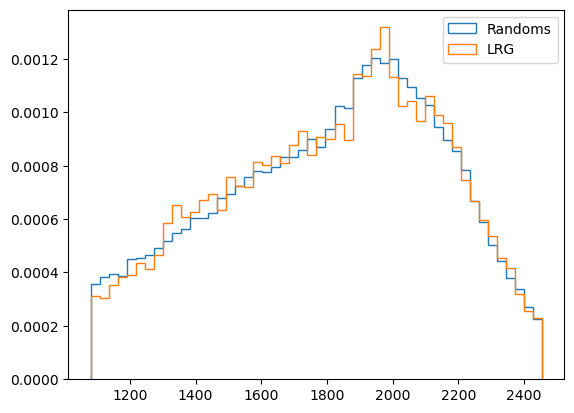

In [ ]:
# Plot distance distribution 
plt.hist(cutsky_FA_rd['Distance'], bins=50, density=True, histtype='step', label='Randoms')
plt.hist(cutsky_FA['Distance'], bins=50, density=True, histtype='step', label='LRG')
plt.legend()
plt.show()

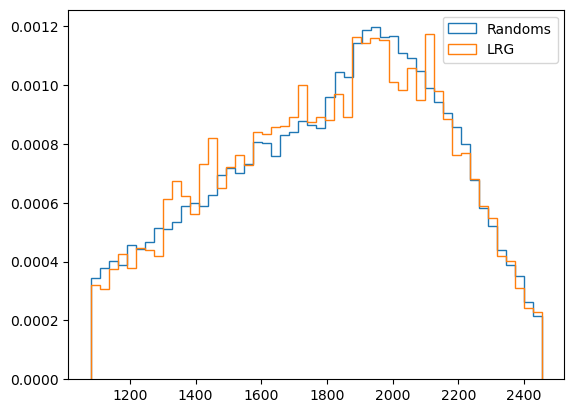

In [ ]:
# Plot distance distribution for AVAILABLE objects only 
plt.hist(cutsky_FA_rd['Distance'][cutsky_FA_rd['AVAILABLE']], bins=50, density=True, histtype='step', label='Randoms')
plt.hist(cutsky_FA['Distance'][cutsky_FA['AVAILABLE']], bins=50, density=True, histtype='step', label='LRG')
plt.legend()
plt.show()

/global/homes/a/arocher/.local/lib/python3.12/site-packages/skyproj/_skyproj.py:628: FutureWarning: skyproj.scatter() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.scatter()
  warnings.warn(
/global/homes/a/arocher/.local/lib/python3.12/site-packages/skyproj/_skyproj.py:673: FutureWarning: skyproj.legend() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.legend()
  warnings.warn(


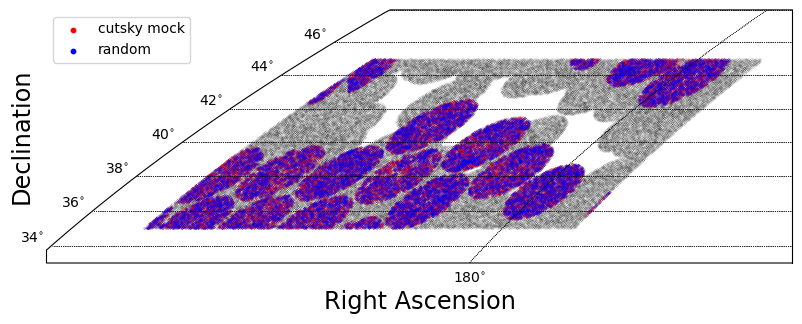

In [9]:
import skyproj
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
# sp.draw_des(label='DES', edgecolor='k')
sp = skyproj.DESSkyproj(ax=ax, extent=[178,209, 33, 48], fontsize=8)

sp.scatter(cutsky_rd['RA'], cutsky_rd['DEC'], s=0.001, c='k')
sp.scatter(cutsky_FA_rd['RA'][cutsky_FA_rd['AVAILABLE']], cutsky_FA_rd['DEC'][cutsky_FA_rd['AVAILABLE']], s=0.01,c='r') 
sp.scatter(cutsky_FA['RA'][cutsky_FA['AVAILABLE']], cutsky_FA['DEC'][cutsky_FA['AVAILABLE']], s=0.01,c='b') 
# sp.scatter(cutsky_FA_rd['RA'][cutsky_FA_rd['OBS_PASS'].T[0]], cutsky_FA_rd['DEC'][cutsky_FA_rd['OBS_PASS'].T[0]], s=0.01,c='r') 
# sp.scatter(cutsky_FA['RA'][cutsky_FA['OBS_PASS'].T[0]], cutsky_FA['DEC'][cutsky_FA['OBS_PASS'].T[0]], s=0.01,c='b') 

sp.scatter(0,0, s=10,c='r', label='cutsky mock') 
sp.scatter(0,0, s=10,c='b', label='random') 



sp.legend()
fig.tight_layout()

In [9]:
import os 
from pycorr import TwoPointCorrelationFunction, setup_logging
import numpy as np
from mockfactory import Catalog
from matplotlib import pyplot as plt
import argparse
import logging
from mpi4py import MPI


logger = logging.getLogger('F.A.')
setup_logging()

def get_2PCF_from_LC(cat, rd_cat, edges, nthreads=256, R1R2=None, weights=None,weights_rd=None, mask=None, mask_rd=None):

    if mask is None:
        mask = np.ones(cat.csize, dtype=bool)
    else:
        if weights is not None:
            weights = weights[mask]
    if mask_rd is None:
        mask_rd = np.ones(rd_cat.csize, dtype=bool)
    else:
        if weights_rd is not None:
            weights_rd = weights_rd[mask_rd]

    result = TwoPointCorrelationFunction('smu', edges,
                                         data_positions1=[cat['RA'][mask], cat['DEC'][mask], cat['Distance'][mask]],
                                         data_positions2=None, engine='corrfunc', position_type='rdd', data_weights1=weights,
                                         randoms_positions1=[rd_cat['RA'][mask_rd], rd_cat['DEC'][mask_rd], rd_cat['Distance'][mask_rd]], randoms_weights1=weights_rd,
                                         boxsize=None, nthreads=nthreads, R1R2=R1R2)

    return result

def get_wp_from_LC(cat, rd_cat, edges, nthreads=256, R1R2=None, weights=None,weights_rd=None, mask=None, mask_rd=None):

    if mask is None:
        mask = np.ones(cat.csize, dtype=bool)
    else:
        if weights is not None:
            weights = weights[mask]
    if mask_rd is None:
        mask_rd = np.ones(rd_cat.csize, dtype=bool)
    else:
        if weights_rd is not None:
            weights_rd = weights_rd[mask_rd]

    result = TwoPointCorrelationFunction('rppi', edges,
                                         data_positions1=[cat['RA'][mask], cat['DEC'][mask], cat['Distance'][mask]],
                                         data_positions2=None, engine='corrfunc', position_type='rdd', data_weights1=weights,
                                         randoms_positions1=[rd_cat['RA'][mask_rd], rd_cat['DEC'][mask_rd], rd_cat['Distance'][mask_rd]], randoms_weights1=weights_rd,
                                         boxsize=None, nthreads=nthreads, R1R2=R1R2)


    return result

In [10]:
from run_pc_for_FA_mocks import get_2PCF_from_LC, get_wp_from_LC

edges = [np.geomspace(0.01, 50, 48), np.linspace(-40, 40, 81)]


result_rppi_avail = get_wp_from_LC(cutsky_FA, cutsky_FA_rd, edges=edges, nthreads=256, mask=cutsky_FA['AVAILABLE'], mask_rd=cutsky_FA_rd['AVAILABLE'])

rp_lcav, wp_lcav = result_rppi_avail(return_sep=True, pimax=40)

result_rppi_FA = get_wp_from_LC(cutsky_FA, cutsky_FA_rd, edges=edges, nthreads=256, mask=(cutsky_FA['NUMOBS']>0), mask_rd=cutsky_FA_rd['AVAILABLE'], R1R2=result_rppi_avail.R1R2)

rp_fa, wp_fa = result_rppi_FA(return_sep=True, pimax=40)

result_rppi_FA_wcomp = get_wp_from_LC(cutsky_FA, cutsky_FA_rd, edges=edges, nthreads=256, mask=(cutsky_FA['NUMOBS']>0), mask_rd=cutsky_FA_rd['AVAILABLE'], R1R2=result_rppi_avail.R1R2, weights=cutsky_FA['COMP_WEIGHT'])
rp_fa_wcomp, wp_fa_wcomp = result_rppi_FA_wcomp(return_sep=True, pimax=40)

[000000.01]  01-15 23:59  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000000.01]  01-15 23:59  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000000.01]  01-15 23:59  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


/global/u1/a/arocher/Code/postdoc/Fiber_assignment/run_pc_for_FA_mocks.py:100: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$s^2 \cdot \\xi_0$')
/global/u1/a/arocher/Code/postdoc/Fiber_assignment/run_pc_for_FA_mocks.py:128: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$r_p \cdot w_p$ [Mpc/$h$]')


[000000.70]  01-15 23:59  TwoPointCorrelationFunction  INFO     Computing two-point counts D1R2.
[000001.21]  01-15 23:59  TwoPointCorrelationFunction  INFO     Computing two-point counts R1R2.
[000001.71]  01-15 23:59  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 1.70 s.
[000001.80]  01-15 23:59  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000001.80]  01-15 23:59  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000001.80]  01-15 23:59  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000002.51]  01-15 23:59  TwoPointCorrelationFunction  INFO     Computing two-point counts D1R2.
[000003.10]  01-15 23:59  TwoPointCorrelationFunction  INFO     Using precomputed two-point counts R1R2.
[000003.10]  01-15 23:59  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 1.30 s.
[000003.11]  01-15 23:59  TwoPointC

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_706493/26954612.py:9: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$r_p \cdot w_p$ [Mpc/$h$]')


Text(0, 0.5, '$r_p \\cdot w_p$ [Mpc/$h$]')

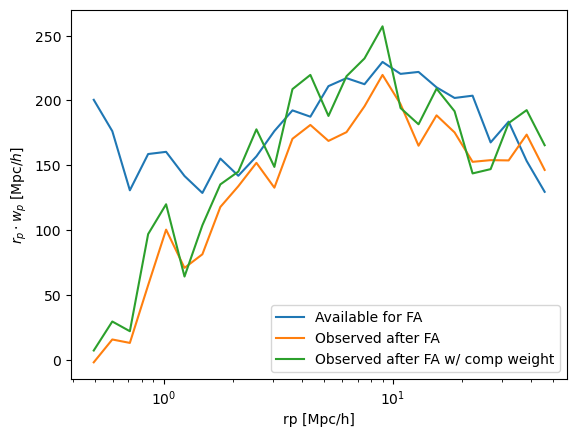

In [11]:
plt.semilogx(rp_lcav, wp_lcav*rp_lcav, label='Available for FA')
# plt.semilogx(rp_lc, wp_lc*rp_lc, label='all')

plt.semilogx(rp_fa, wp_fa*rp_fa, label='Observed after FA')
plt.semilogx(rp_fa_wcomp, wp_fa_wcomp*rp_fa_wcomp, label='Observed after FA w/ comp weight')

plt.legend()
plt.xlabel('rp [Mpc/h]')
plt.ylabel('$r_p \cdot w_p$ [Mpc/$h$]')


# Create random desi NGC catalog

In [13]:
from mockfactory import RandomCutskyCatalog
from mockfactory.desi import is_in_desi_footprint

custsky_rd = RandomCutskyCatalog(rarange=(85, 300), decrange=(-15, 90), drange=(0, 3000), nbar=1000, seed=42)
is_in_desi = is_in_desi_footprint(custsky_rd['RA'], custsky_rd['DEC'], release='Y3', program='dark')
custsky_rd_in_desi = custsky_rd[is_in_desi]


In [14]:
from mockfactory import TabulatedRadialMask, DistanceToRedshift
from cosmoprimo.fiducial import DESI
import numpy as np 
def _apply_radial_mask(catalog, nz, zmin=0., zmax=6., seed=42, norm=None):
    print('Applying radial mask.')
    from mockfactory import TabulatedRadialMask, DistanceToRedshift
    from cosmoprimo.fiducial import DESI
    cosmo = DESI()
    distance_to_redshift = DistanceToRedshift(distance=cosmo.comoving_radial_distance)
    nz_filename = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/LRG_NGC_nz.txt'
    zbin_min, zbin_max, n_z = np.genfromtxt(nz_filename, usecols=(1, 2, 3)).T
    mask_radial = TabulatedRadialMask(z=np.linspace(zbin_min[0], zbin_max[-1], len(n_z)), nbar=n_z, interp_order=2,
                                                    norm=norm)
    return catalog[mask_radial(distance_to_redshift(catalog['Distance']), seed=seed)]

custsky_rd_in_desi = _apply_radial_mask(custsky_rd_in_desi, nz=None, zmin=0., zmax=6., seed=42, norm=None)

Applying radial mask.


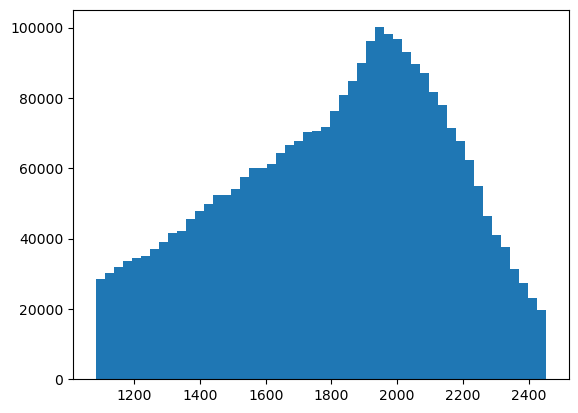

In [ ]:
#Plot distance distribution
from matplotlib import pyplot as plt
plt.hist(custsky_rd_in_desi['Distance'], bins=50)
plt.show()

/global/u1/a/arocher/Code/postdoc/4MOST/4MOST_CRS_tools/CRStools/utils.py:328: SyntaxWarning: invalid escape sequence '\p'
  """Shift `ra` to the origin of the Axes object and convert to radians.
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20251214-1.0.0/conda/lib/python3.12/site-packages/healpy/visufunc.py:835: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))
/global/u1/a/arocher/Code/postdoc/4MOST/4MOST_CRS_tools/CRStools/utils.py:1183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


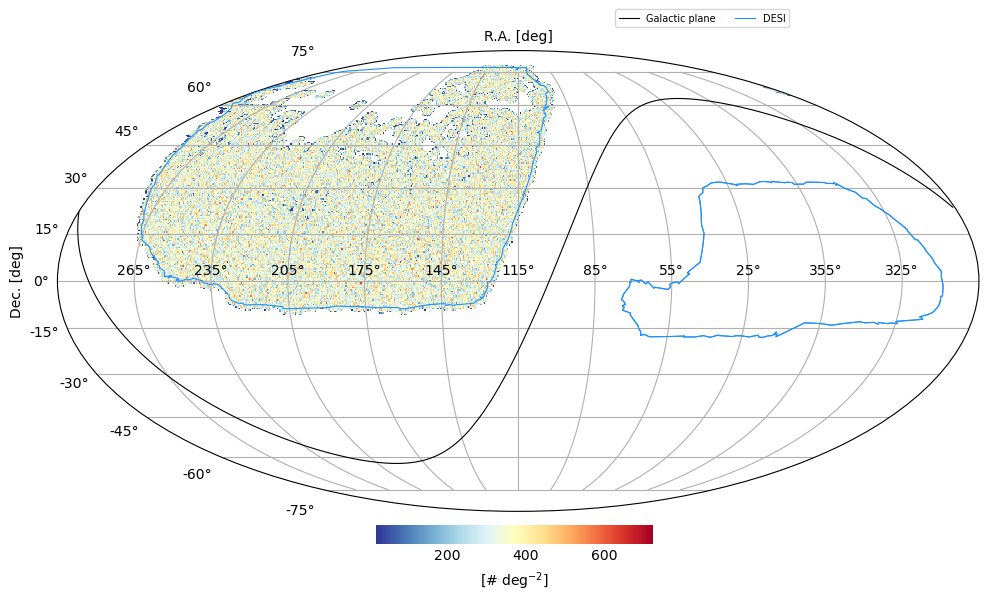

In [16]:
# To show on a healpix map 
# to install CRStools:
# git clone https://github.com/4most-crs/4MOST_CRS_tools.git 
# cd 4MOST_CRS_tools
# python -m pip install -e . --user

from CRStools import utils 
hpmap = utils.create_hp_map(custsky_rd_in_desi['RA'], custsky_rd_in_desi['DEC'], nside=256)
utils.plot_moll(hpmap, figsize=(10,8), desi_footprint=True)


## Compute 2PCF comparison 

### You can run FA for mock and random on a single node using the script run_FA_for_mock.py it should take few minutes.

```
srun -n 64 python run_FA_for_mock.py --input_catalog /pscratch/sd/e/epaillas/acm/dr2/hods/cutsky/v0.0/c000_ph000/LRG_NGC_hod000.dat.fits --output_catalog /pscratch/sd/a/arocher/LRG_NGC_hod000_with_FA.dat.fits --npasses 7 --release Y3 --program dark 
srun -n 64 python run_FA_for_mock.py --input_catalog /pscratch/sd/a/arocher/randoms_LRG_NGC_hod000_nz.dat.fits --output_catalog /pscratch/sd/a/arocher/randoms_LRG_NGC_hod000_with_FA_nz.dat.fits --npasses 7 --release Y3 --program dark 
```

### Then you can compute the 2PCF using the script run_pc_for_FA_mocks.py or just run it in the nb (~few minutes)
```srun -N 1 python run_pc_for_FA_mocks.py --input_catalog /pscratch/sd/a/arocher/LRG_NGC_hod000_with_FA.dat.fits --input_rd_catalog /pscratch/sd/a/arocher/randoms_LRG_NGC_hod000_with_FA_nz.dat.fits ```

Output correlations and plots will be saved in a new repository 2PCF_FA_results. You can give the output directory path using the command --output_dir  

[000680.12]  01-16 00:10  FileStack                    INFO     Reading /pscratch/sd/a/arocher/LRG_NGC_hod000_with_FA.dat.fits.


<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_706493/2135463278.py:28: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$s^2 \cdot \\xi_0$')


[000681.57]  01-16 00:10  FileStack                    INFO     Reading /pscratch/sd/a/arocher/randoms_LRG_NGC_hod000_with_FA_nz.dat.fits.
[000694.66]  01-16 00:10  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000694.66]  01-16 00:10  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[000694.66]  01-16 00:10  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000708.02]  01-16 00:10  TwoPointCorrelationFunction  INFO     Computing two-point counts D1R2.
[000772.02]  01-16 00:11  TwoPointCorrelationFunction  INFO     Computing two-point counts R1R2.
[000867.89]  01-16 00:13  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 173.23 s.
[000868.99]  01-16 00:13  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[000868.99]  01-16 00:13  TwoPointCorrelationFunction  INFO     Runn

Text(0, 0.5, '$s^2 \\cdot \\xi_0$')

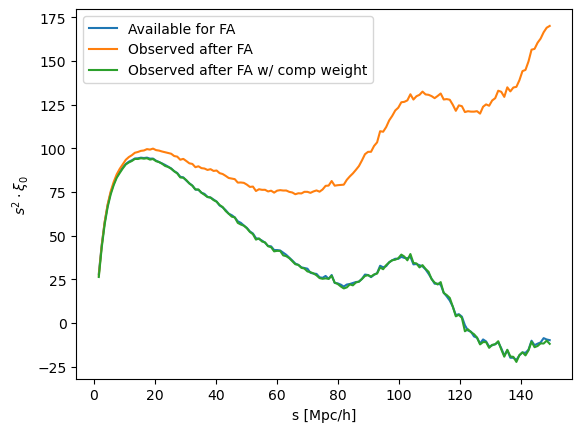

In [17]:
# Afetr having run FA on the cutsky and random mocks

cutsky = Catalog.read('/pscratch/sd/a/arocher/LRG_NGC_hod000_with_FA.dat.fits')
if 'AVAILABLE' not in cutsky.columns():
    raise ValueError('The cutsky catalog must have an AVAILABLE column indicating which targets were assigned fibers')

mask_tr = (cutsky['TRACER'] == 'LRG')
cutsky_rd = Catalog.read('/pscratch/sd/a/arocher/randoms_LRG_NGC_hod000_with_FA_nz.dat.fits')

edges_smu = [np.linspace(1, 150, 151), np.linspace(-1, 1, 201)]
result_smu_avail = get_2PCF_from_LC(cutsky, cutsky_rd, edges=edges_smu, nthreads=256, mask=mask_tr & cutsky['AVAILABLE'], mask_rd=cutsky_rd['AVAILABLE'])

s_lc, (xi0_lc, xi2_lc) = result_smu_avail(return_sep=True, ells=[0,2])


result_smu_FA = get_2PCF_from_LC(cutsky, cutsky_rd, edges=edges_smu, nthreads=256, mask=mask_tr & (cutsky['NUMOBS']>0), mask_rd=cutsky_rd['AVAILABLE'], R1R2=result_smu_avail.R1R2)

s_fa, (xi0_fa, xi2_fa) = result_smu_FA(return_sep=True, ells=[0,2])

result_smu_FA_wcomp = get_2PCF_from_LC(cutsky, cutsky_rd, edges=edges_smu, nthreads=256, mask=mask_tr & (cutsky['NUMOBS']>0), mask_rd=cutsky_rd['AVAILABLE'], R1R2=result_smu_avail.R1R2, weights=cutsky['COMP_WEIGHT'])
s_fa_wcomp, (xi0_fa_wcomp, xi2_fa_wcomp) = result_smu_FA_wcomp(return_sep=True, ells=[0,2])


plt.plot(s_lc, xi0_lc*s_lc**2, label='Available for FA')
plt.plot(s_fa, xi0_fa*s_fa**2, label='Observed after FA')
plt.plot(s_fa_wcomp, xi0_fa_wcomp*s_fa_wcomp**2, label='Observed after FA w/ comp weight')

plt.legend()
plt.xlabel('s [Mpc/h]')
plt.ylabel('$s^2 \cdot \\xi_0$')


<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_706493/417790354.py:22: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$r_p \cdot w_p$ [Mpc/$h$]')


[001032.00]  01-16 00:16  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[001032.00]  01-16 00:16  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[001032.00]  01-16 00:16  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[001037.12]  01-16 00:16  TwoPointCorrelationFunction  INFO     Computing two-point counts D1R2.
[001058.80]  01-16 00:16  TwoPointCorrelationFunction  INFO     Computing two-point counts R1R2.
[001093.04]  01-16 00:17  TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 61.05 s.
[001093.55]  01-16 00:17  TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.LandySzalayTwoPointEstimator'>.
[001093.55]  01-16 00:17  TwoPointCorrelationFunction  INFO     Running auto-correlation.
[001093.55]  01-16 00:17  TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[001098.01]  01-16 00

Text(0, 0.5, '$r_p \\cdot w_p$ [Mpc/$h$]')

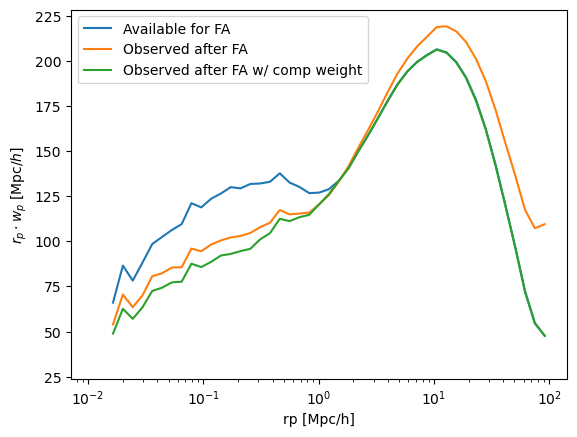

In [18]:

edges_rppi = [np.geomspace(0.01, 100, 48), np.linspace(-40, 40, 81)]

result_rppi_avail = get_wp_from_LC(cutsky, cutsky_rd, edges=edges_rppi, nthreads=256, mask=mask_tr & cutsky['AVAILABLE'], mask_rd=cutsky_rd['AVAILABLE'])

rp_lc, wp_lc = result_rppi_avail(return_sep=True, pimax=40)


result_rppi_FA = get_wp_from_LC(cutsky, cutsky_rd, edges=edges_rppi, nthreads=256, mask=mask_tr & (cutsky['NUMOBS']>0), mask_rd=cutsky_rd['AVAILABLE'], R1R2=result_rppi_avail.R1R2)

rp_fa, wp_fa = result_rppi_FA(return_sep=True, pimax=40)

result_rppi_FA_wcomp = get_wp_from_LC(cutsky, cutsky_rd, edges=edges_rppi, nthreads=256, mask=mask_tr & (cutsky['NUMOBS']>0), mask_rd=cutsky_rd['AVAILABLE'], R1R2=result_rppi_avail.R1R2, weights=cutsky['COMP_WEIGHT'])
rp_fa_wcomp, wp_fa_wcomp = result_rppi_FA_wcomp(return_sep=True, pimax=40)


plt.semilogx(rp_lc, wp_lc*rp_lc, label='Available for FA')
plt.semilogx(rp_fa, wp_fa*rp_fa, label='Observed after FA')
plt.semilogx(rp_fa_wcomp, wp_fa_wcomp*rp_fa_wcomp, label='Observed after FA w/ comp weight')

plt.legend()
plt.xlabel('rp [Mpc/h]')
plt.ylabel('$r_p \cdot w_p$ [Mpc/$h$]')

